# 05 - Results Comparison
Compare validation curves, computational efficiency, and held-out test accuracy for ACE vs MACE.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

try:
    ace_df = pd.read_csv("../data/ace_metrics_100.csv")
    mace_df = pd.read_csv("../data/mace_metrics_100.csv")
    ace_test_df = pd.read_csv("../data/ace_test_metrics_100.csv")
    mace_test_df = pd.read_csv("../data/mace_test_metrics_100.csv")
except FileNotFoundError:
    print("Please run Notebooks 02 and 03 first to generate train/val and test metrics!")
    raise

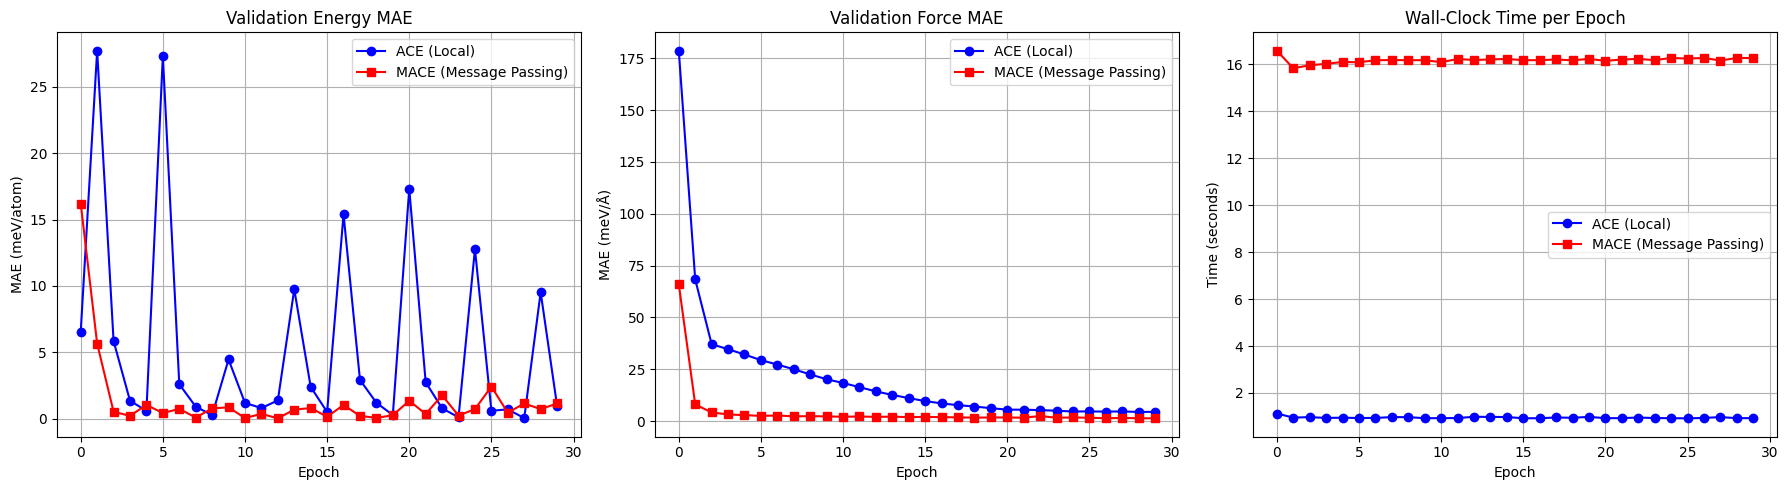

Image saved successfully!


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot Energy MAE
axes[0].plot(ace_df["epoch"], ace_df["val_e_mae"], label="ACE (Local)", color='blue', marker='o')
axes[0].plot(mace_df["epoch"], mace_df["val_e_mae"], label="MACE (Message Passing)", color='red', marker='s')
axes[0].set_title("Validation Energy MAE")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MAE (meV/atom)")
axes[0].legend()
axes[0].grid(True)

# Plot Force MAE
axes[1].plot(ace_df["epoch"], ace_df["val_f_mae"], label="ACE (Local)", color='blue', marker='o')
axes[1].plot(mace_df["epoch"], mace_df["val_f_mae"], label="MACE (Message Passing)", color='red', marker='s')
axes[1].set_title("Validation Force MAE")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE (meV/Å)")
axes[1].legend()
axes[1].grid(True)

# Plot Training Time per Epoch
axes[2].plot(ace_df["epoch"], ace_df["time"], label="ACE (Local)", color='blue', marker='o')
axes[2].plot(mace_df["epoch"], mace_df["time"], label="MACE (Message Passing)", color='red', marker='s')
axes[2].set_title("Wall-Clock Time per Epoch")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Time (seconds)")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.savefig('../data/final_comparison_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print("Image saved successfully!")

In [3]:
# Summary Table
summary = pd.DataFrame({
    "Model": ["ACE", "MACE"],
    "Best Val Energy MAE (meV/at)": [ace_df["val_e_mae"].min(), mace_df["val_e_mae"].min()],
    "Best Val Force MAE (meV/A)": [ace_df["val_f_mae"].min(), mace_df["val_f_mae"].min()],
    "Test Energy MAE (meV/at)": [ace_test_df["test_e_mae"].iloc[0], mace_test_df["test_e_mae"].iloc[0]],
    "Test Force MAE (meV/A)": [ace_test_df["test_f_mae"].iloc[0], mace_test_df["test_f_mae"].iloc[0]],
    "Avg Time per Epoch (s)": [ace_df["time"].mean(), mace_df["time"].mean()],
    "Total Epochs": [len(ace_df), len(mace_df)],
    "Total Training Time (s)": [ace_df["time"].sum(), mace_df["time"].sum()]
})
summary

,Model,Best Val Energy MAE (meV/at),Best Val Force MAE (meV/A),Test Energy MAE (meV/at),Test Force MAE (meV/A),Avg Time per Epoch (s),Total Epochs,Total Training Time (s)
0,ACE,0.046949,4.425655,0.981591,4.773481,0.952532,30,28.575967
1,MACE,0.028699,1.328923,1.145449,1.468426,16.175705,30,485.271152


## Experiment A: Data Volume Scaling
To evaluate the data efficiency of the models, we assess performance scaling by training ACE and MACE on 10%, 40%, 70%, and 100% of the available dataset.

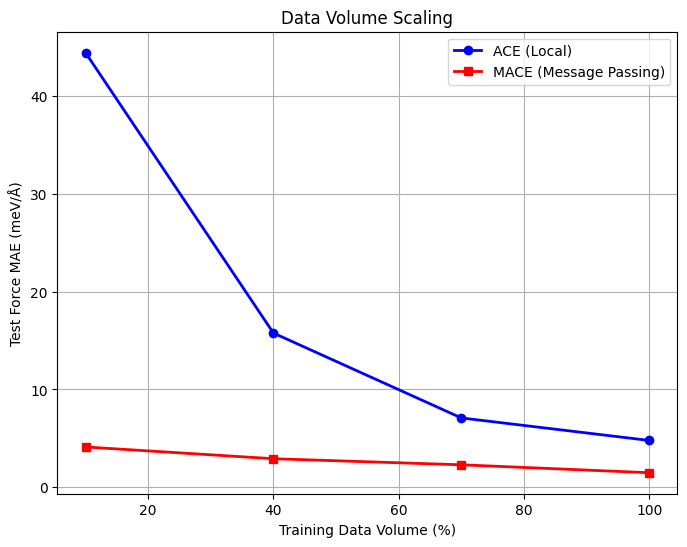

In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt

fractions = [10, 40, 70, 100]
ace_test_errs = []
mace_test_errs = []

for frac in fractions:
    ace_path = f"../data/ace_test_metrics_{frac}.csv"
    mace_path = f"../data/mace_test_metrics_{frac}.csv"
    
    if os.path.exists(ace_path):
        ace_test_errs.append(pd.read_csv(ace_path)["test_f_mae"].iloc[0])
    else:
        ace_test_errs.append(float('nan'))
        
    if os.path.exists(mace_path):
        mace_test_errs.append(pd.read_csv(mace_path)["test_f_mae"].iloc[0])
    else:
        mace_test_errs.append(float('nan'))

plt.figure(figsize=(8, 6))
plt.plot(fractions, ace_test_errs, marker='o', label="ACE (Local)", color='blue', linewidth=2)
plt.plot(fractions, mace_test_errs, marker='s', label="MACE (Message Passing)", color='red', linewidth=2)
plt.xlabel("Training Data Volume (%)")
plt.ylabel("Test Force MAE (meV/Å)")
plt.title("Data Volume Scaling")
plt.legend()
plt.grid(True)
plt.savefig('../data/data_scaling_plot.png', dpi=300, bbox_inches='tight')
plt.show()

## Experiment B: Computational Cost vs. Accuracy
Compare the forward-pass inference time (from `04_Inference_Benchmark`) against the test Force MAE to analyze the computational cost versus accuracy trade-off.

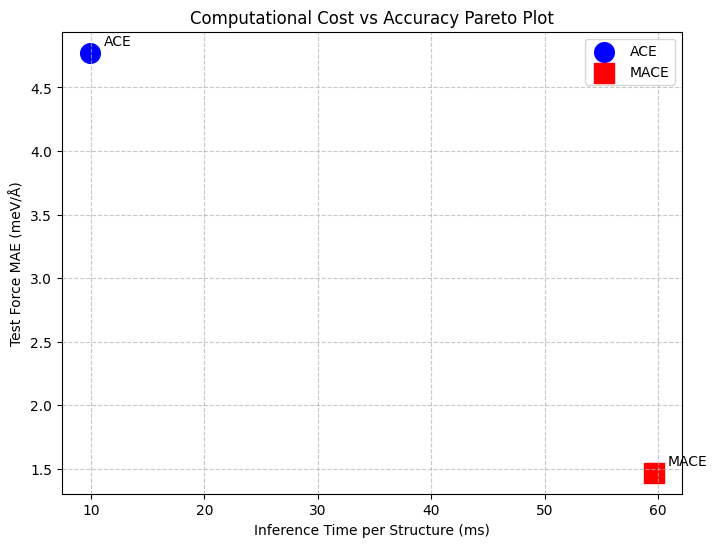

In [5]:
try:
    inf_df = pd.read_csv("../data/inference_metrics.csv")
    
    # Get 100% test errs from the table we already have
    ace_inf = inf_df[inf_df["Model"] == "ACE"]["Inference_Time_ms"].iloc[0]
    mace_inf = inf_df[inf_df["Model"] == "MACE"]["Inference_Time_ms"].iloc[0]
    
    ace_err = ace_test_df["test_f_mae"].iloc[0]
    mace_err = mace_test_df["test_f_mae"].iloc[0]
    
    plt.figure(figsize=(8, 6))
    plt.scatter([ace_inf], [ace_err], s=200, label="ACE", color='blue', marker='o')
    plt.scatter([mace_inf], [mace_err], s=200, label="MACE", color='red', marker='s')
    
    plt.xlabel("Inference Time per Structure (ms)")
    plt.ylabel("Test Force MAE (meV/Å)")
    plt.title("Computational Cost vs Accuracy Pareto Plot")
    
    # Annotate points
    plt.annotate("ACE", (ace_inf, ace_err), xytext=(10, 5), textcoords='offset points')
    plt.annotate("MACE", (mace_inf, mace_err), xytext=(10, 5), textcoords='offset points')
    
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.savefig('../data/cost_vs_accuracy_plot.png', dpi=300, bbox_inches='tight')
    plt.show()
except FileNotFoundError:
    print("inference_metrics.csv not found. Please run 05_Inference_Benchmark.ipynb first.")

## Experiment C: Parity Plots (Predicted vs True)
We visualize the predictive spread of the 100% trained models on the held-out test set.

Pre-computing graphs for 200 structures (cutoff=5.0 Å)...


Building graphs:   0%|          | 0/200 [00:00<?, ?it/s]

  Done. Dataset ready (200 graphs).


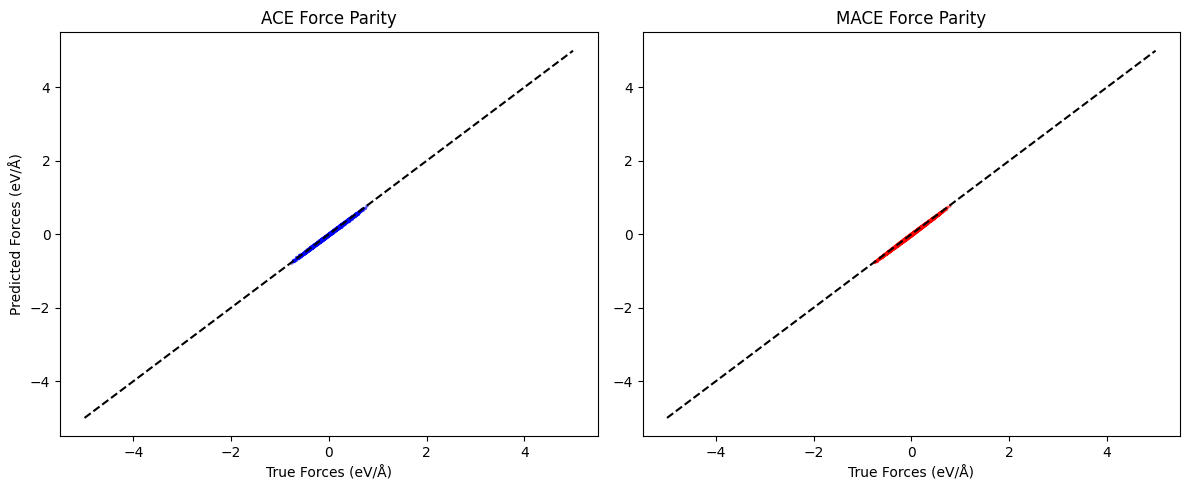

In [6]:
import torch
import sys
sys.path.append('..')
from src.dataset import MDTrajectoryDataset
from src.models.ace_wrapper import ACEWrapper
from src.models.mace_wrapper import MACEWrapper
from torch_geometric.loader import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"

# Load Test Data
test_ds = MDTrajectoryDataset("../data/test.extxyz", cutoff=5.0)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

# Load 100% Models
ace_model = ACEWrapper(num_elements=120, num_radial=8, l_max=2, r_cut=5.0, hidden_dim=32).to(device)
ace_model.load_state_dict(torch.load("../data/ace_model_100.pth", map_location=device))
ace_model.eval()

mace_model = MACEWrapper(num_elements=120, r_cut=5.0, num_radial=8, l_max=2, num_blocks=2, node_dim=16).to(device)
mace_model.load_state_dict(torch.load("../data/mace_model_100.pth", map_location=device))
mace_model.eval()

def get_predictions(model):
    true_f, pred_f = [], []
    with torch.set_grad_enabled(True):
        for batch in test_loader:
            batch = batch.to(device)
            out = model(batch)
            true_f.extend(batch.forces.cpu().numpy().flatten())
            pred_f.extend(out['forces'].detach().cpu().numpy().flatten())
    return true_f, pred_f

ace_true_f, ace_pred_f = get_predictions(ace_model)
mace_true_f, mace_pred_f = get_predictions(mace_model)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(ace_true_f, ace_pred_f, alpha=0.3, color='blue', s=2)
axes[0].plot([-5, 5], [-5, 5], 'k--')
axes[0].set_title("ACE Force Parity")
axes[0].set_xlabel("True Forces (eV/Å)")
axes[0].set_ylabel("Predicted Forces (eV/Å)")

axes[1].scatter(mace_true_f, mace_pred_f, alpha=0.3, color='red', s=2)
axes[1].plot([-5, 5], [-5, 5], 'k--')
axes[1].set_title("MACE Force Parity")
axes[1].set_xlabel("True Forces (eV/Å)")

plt.tight_layout()
plt.savefig('../data/parity_plot.png', dpi=300)
plt.show()